In [1]:
from models.vqvae_single import VQVAE_Single
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision

In [2]:
from datasets.hqseg44k import HQSeg44KTrainDataset, HQSeg44KTestDataset
from datasets.coco_lvis import LvisDataset

In [3]:
# 创建数据加载器
dataset = HQSeg44KTrainDataset(data_root='data/sam-hq')
# dataset = HQSeg44KTestDataset(data_root='data/sam-hq')

In [4]:
# VOCAB_SIZE = 4096  # 码本大小
# Z_CHANNELS = 48   # 潜在空间通道数
# BASE_CHANNELS = 192  # 基础通道数
# BETA = 0.25  # commitment loss权重
DEVICE = torch.device(f'cuda' if torch.cuda.is_available() else 'cpu')
# DEVICE = 'cpu'

In [5]:
# torch.save(vqvae.state_dict(), 'ckpt/vqvae_single.pth')

In [5]:
from utils.metrics import calc_iou

def visualize(item):
    image, mask, instance_info = item

    mask = torch.from_numpy(mask)
    print(mask.shape)
    mask = mask.permute(2, 0, 1)
    mask = mask * 2 - 1

    # result = vqvae.img_to_reconstructed_img(mask.to(DEVICE).unsqueeze(0))
    indices = vqvae.img_to_idxBl(mask.to(DEVICE).unsqueeze(0))
    result = vqvae.idxBl_to_img(indices, same_shape=True)
    tokens = indices[-1].reshape(32, 32)
    print(len(indices), indices[-1].shape, tokens)
    channel_r = (tokens // 256)
    channel_g = (tokens // 16) % 16
    channel_b = tokens % 16
    token_map = torch.stack([channel_r, channel_b, channel_g]) / 16
    token_map = F.interpolate(token_map.unsqueeze(0), (256, 256), mode='nearest').squeeze(0)
    # result_conv = [edge(item) for item in result]
    logit = result[-1].squeeze(0).expand(3, -1, -1)
    mask_image = mask.to(DEVICE).expand(3, -1, -1)
    chw = torchvision.utils.make_grid(torch.stack([(logit > 0), mask_image, F.sigmoid(logit) , token_map * 0.3 + mask_image * 0.7],), nrow=2, padding=1, pad_value=1.0)

    print(mask.shape, result[-1].shape)

    iou = calc_iou(result[-1], mask.to(DEVICE).unsqueeze(0))
    print(f'iou: {iou}')
    chw = chw.permute(1, 2, 0).mul_(255).cpu().numpy()
    print(chw.shape)
    chw = Image.fromarray(chw.astype(np.uint8))
    return chw

In [6]:
from maskseg_build_everything import build_vqvae_single_monoscale_v2, build_vqvae_single_monoscale_v2_1, build_vqvae_single_monoscale_v2_2, build_vqvae_single_v3
# checkpoint_path = 'vqvae_single_v3_epoch_11.pth'
checkpoint_path = 'ckpt/s_vqvae_single_monoscale_v2_epoch_5.pth'
# vqvae = build_vqvae_single_monoscale_v2_2()
vqvae = build_vqvae_single_monoscale_v2()

vqvae.load_state_dict(torch.load(checkpoint_path, map_location='cpu'))

ModuleNotFoundError: No module named 'huggingface_hub'

torch.Size([256, 256, 1])
1 torch.Size([1, 1024]) tensor([[1519,  731, 1860,  ..., 1860, 1860, 1860],
        [3405,  252,  252,  ..., 1860, 1860, 1519],
        [ 916, 1933,  272,  ..., 1860, 1860, 1860],
        ...,
        [1860, 1860, 1700,  ..., 1860, 1860, 1860],
        [1519, 1860, 2853,  ..., 1860, 1860, 1860],
        [1860, 1860,  731,  ..., 1860, 1860, 1145]])
torch.Size([1, 256, 256]) torch.Size([1, 1, 256, 256])
iou: tensor([0.9040])
(515, 515, 3)


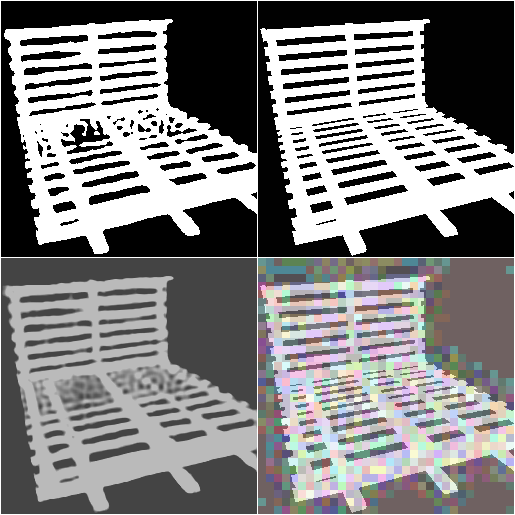

In [21]:
visualize(dataset[233])